## Asli ML Starts !
### he he 😉

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 🚀 Universal ML Implementation Template

Copy and paste this into a `.py` file or a Jupyter Notebook cell. This structure works for almost any Scikit-Learn project.

```python
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. DATA LOADING & INSPECTION
df = pd.read_csv('your_data.csv') 
print(f"Shape: {df.shape}")
print(df.isna().sum())       # Check for missing values
print(df.dtypes)             # Check data types

# 2. PREPROCESSING & CLEANING
# Fill numerical missing values with median
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Convert Categorical to Numerical (One-Hot Encoding)
df = pd.get_dummies(df, drop_first=True)

# 3. FEATURE & TARGET SELECTION
X = df.drop('target_column', axis=1) # Replace with your target name
y = df['target_column']

# 4. TRAIN-TEST SPLIT
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. FEATURE SCALING (Required for most models like SVM, KNN, Linear)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # Transform only using train stats

# 6. MODEL SELECTION & TRAINING
from sklearn.ensemble import RandomForestClassifier 
# OR: from sklearn.linear_model import LinearRegression (for numbers)

model = RandomForestClassifier()
model.fit(X_train, y_train)

# 7. EVALUATION
from sklearn.metrics import classification_report, confusion_matrix, r2_score

predictions = model.predict(X_test)

# For Classification:
print("Classification Report:\n", classification_report(y_test, predictions))
# For Regression (uncomment if needed):
# print("R2 Score:", r2_score(y_test, predictions))

# 8. HYPERPARAMETER TUNING (Optimization)
from sklearn.model_selection import GridSearchCV

param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 10, 20]}
grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5)
grid.fit(X_train, y_train)

print(f"Best Parameters: {grid.best_params_}")
final_model = grid.best_estimator_


In [6]:
df=pd.read_csv("../datasets/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


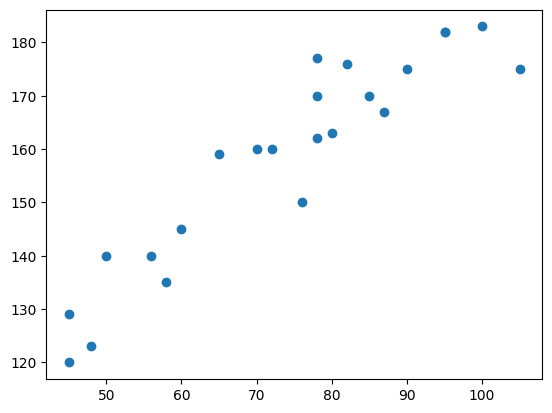

In [7]:
plt.scatter(df["Weight"], df["Height"])
# From this curve we can see the Linear relation b/w hieght and weight

In [8]:
# Finding the correlation b/w both params:
df.corr()



,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000



- Strong positive correlation
- As Height increases the Weight also increases
- Relationship is almost linear

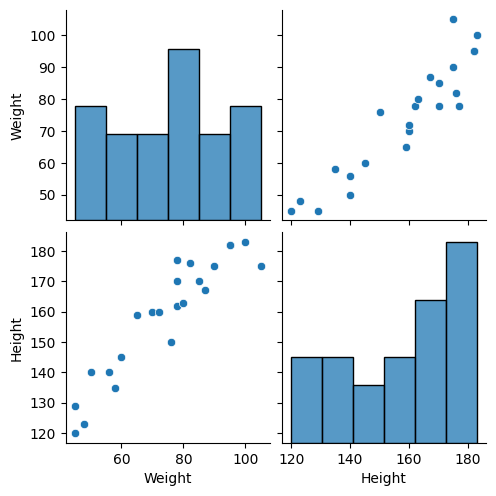

In [9]:
import seaborn as sns
sns.pairplot(df)

# Pre-requisite steps.

In [10]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


In [11]:
df.isna()
df.isnull().sum()

Weight    0
Height    0
dtype: int64

In [29]:
# Defining dependent and independent vars. 

# NOTE : Independent vars must be of type dataframe or a 2D array always. 
x=df[["Weight"]] #This is Independent feature. 
y= df["Height"] #dependent feature is 1D array. 

# We can also see their shape of these matrices.
print(np.array(x).shape)
np.array(y).shape

(23, 1)


(23,)

# Test-train-split of the data .

In [13]:
# Test train and splittinf the data:
from sklearn.model_selection import train_test_split


In [30]:
# Splitting 80% for training and 20% for testing
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=42)

In [ ]:
# from above code we got np.array(X).shape =(23,1) an for y.shape= 23. 
print(X_train.shape)
print(y_train.shape)
print(y_test.shape)
print(X_test.shape)


(17, 1)
(17,)
(6,)
(6, 1)


## Standardization 

- We do it becoz suppose in this case we have differnent unit weight(kg) and height(cm) thus if one of the values is larger then andother feature is very smaller then our gradient descent (inverted U ) will be much steeper and thus more time to calc. G min

- Thus we do the std. by applying z-score to each value of features(ht. and wt. ) .
- In this std. we consider the mean =0 and variance=1.
- Folowing formula is used.

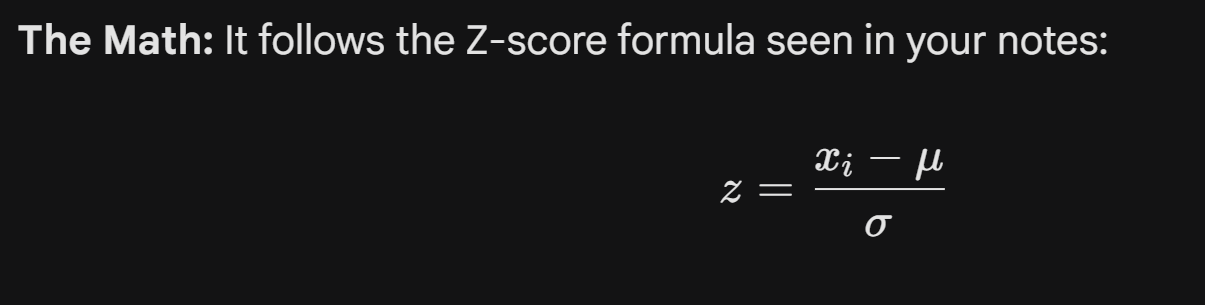

In [32]:
# Standardization :
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [36]:
# NOTE : We always use fit_transform for the training data (independent var)

X_train_scaled = scaler.fit_transform(X_train)



In [38]:
# NOTE: Here we use .transform for the training data becoz :
# if we used fit_transform the z-score for the test data will be calc wit the new mean and variance
# But we wanna have the same mean and var for the test data. 
# Also it prevents the "Data leakage" where some of the training data  may get to test data.
X_test_scaled = scaler.transform(X_test)


# Apply LR

In [46]:
from sklearn.linear_model import LinearRegression

regression = LinearRegression()
regression.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [ ]:
print("intercept:", regression.intercept_) #where the line is meeting the y-axis or where the line meets at wt  = 0 . 

# prints the coeff for the LR model eqn
print("coeff or slope :",regression.coef_) # it means 1 unit movement in ht. => 17.2 units movement in wt.


intercept: 156.47058823529412
coeff or slope : [17.2982057]


# plotting the bfl:

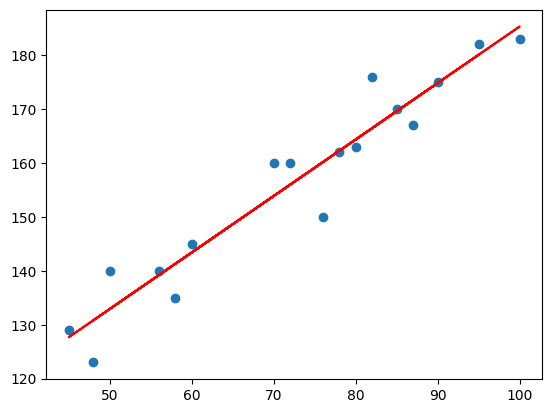

In [50]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), color="red")

# Prediction of the test data :

In [55]:
y_pred=regression.predict(X_test)


# Performance metrics:

In [59]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, mean_squared_error
mae=mean_absolute_error(y_test, y_pred)
mse=mean_squared_error(y_test, y_pred)
rmse=np.sqrt(mse)
print("RMSE: ", rmse)
print("MAE: ", mae)
print("MSE: ", mse)

# R-sq score:
from sklearn.metrics import r2_score
r_sq=r2_score(y_test, y_pred)
print("R-sq. :", r_sq)

# Adj r-sq value:
adj_r_sq= 1-(1-r_sq)*(len(y_test)-1)/(len(y_test)- X_test.shape[1] -1)
print("Adj R-sq :", adj_r_sq)


RMSE:  10.7163749912126
MAE:  9.665125886795005
MSE:  114.84069295228686
R-sq. : 0.7360826717981279
Adj R-sq : 0.6701033397476599


# OLS (Ordinary Least Sq. :)
### Estimating various metrics using OLS.


In [61]:
import statsmodels.api as sm

model=sm.OLS(y_train, X_train).fit()
pridxn=model.predict(X_test)
print(pridxn)

15    164.134205
9     164.134205
0      94.692811
8     199.907045
17    136.778504
12    220.949891
dtype: float64


In [62]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.986
Model:                            OLS   Adj. R-squared (uncentered):              0.985
Method:                 Least Squares   F-statistic:                              1133.
Date:                Sat, 28 Mar 2026   Prob (F-statistic):                    2.80e-16
Time:                        18:34:14   Log-Likelihood:                         -73.806
No. Observations:                  17   AIC:                                      149.6
Df Residuals:                      16   BIC:                                      150.4
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------